In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
df = pd.read_excel("WHR26_Data_Figure_2.1.xlsx")

df.head()

df = df.rename(columns={
    "Country name": "Country",
    "Life evaluation (3-year average)": "Life_Evaluation",
    "Explained by: Log GDP per capita": "GDP_per_Capita",
    "Explained by: Social support": "Social_Support",
    "Explained by: Healthy life expectancy": "Healthy_Life_Expectancy",
    "Explained by: Freedom to make life choices": "Freedom",
    "Explained by: Generosity": "Generosity",
    "Explained by: Perceptions of corruption": "Corruption"
})

Rows: 2116
Columns: 13

Missing values:
Life_Evaluation       0
Social_Support     1097
dtype: int64

Duplicate rows:
0


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df[["Life_Evaluation", "Social_Support"]].isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

df[["Life_Evaluation", "Social_Support"]].describe()

Rows: 2116
Columns: 13

Missing values:
Life_Evaluation       0
Social_Support     1097
dtype: int64

Duplicate rows:
0
Median Social Support: 1.14011859893799


In [10]:
median_support = df["Social_Support"].median()

print("Median Social Support:", median_support)

df["Support_Group"] = np.where(
    df["Social_Support"] >= median_support,
    "High Social Support",
    "Low Social Support"
)

df["Support_Group"].value_counts()
group_stats = df.groupby("Support_Group")["Life_Evaluation"].agg(
    ["count", "mean", "std", "median"]
)

group_stats

Median Social Support: 1.14011859893799


,count,mean,std,median
Support_Group,,,,
High Social Support,510,6.192131,0.793865,6.21825
Low Social Support,1606,5.234956,1.115175,5.14900


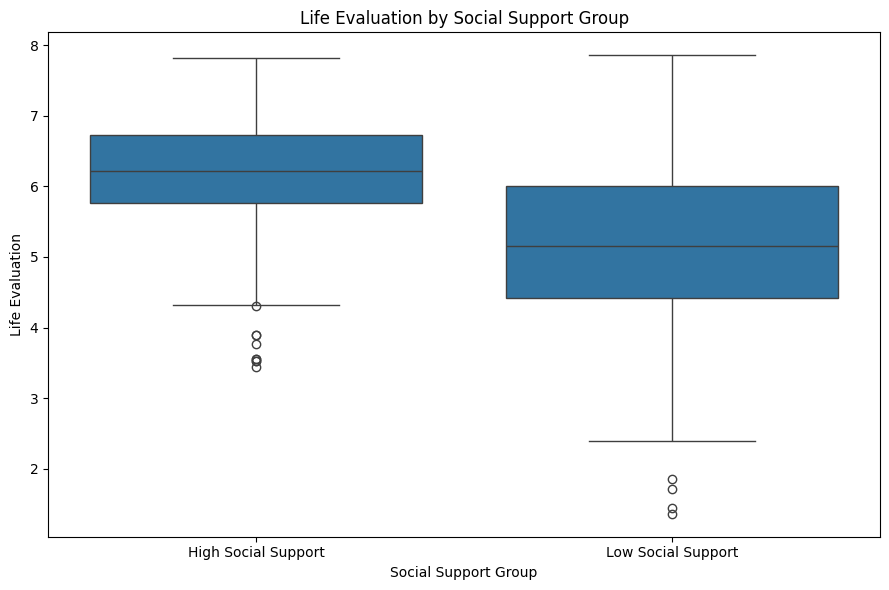

In [11]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Support_Group",
    y="Life_Evaluation"
)

plt.title("Life Evaluation by Social Support Group")
plt.xlabel("Social Support Group")
plt.ylabel("Life Evaluation")

plt.tight_layout()
plt.show()

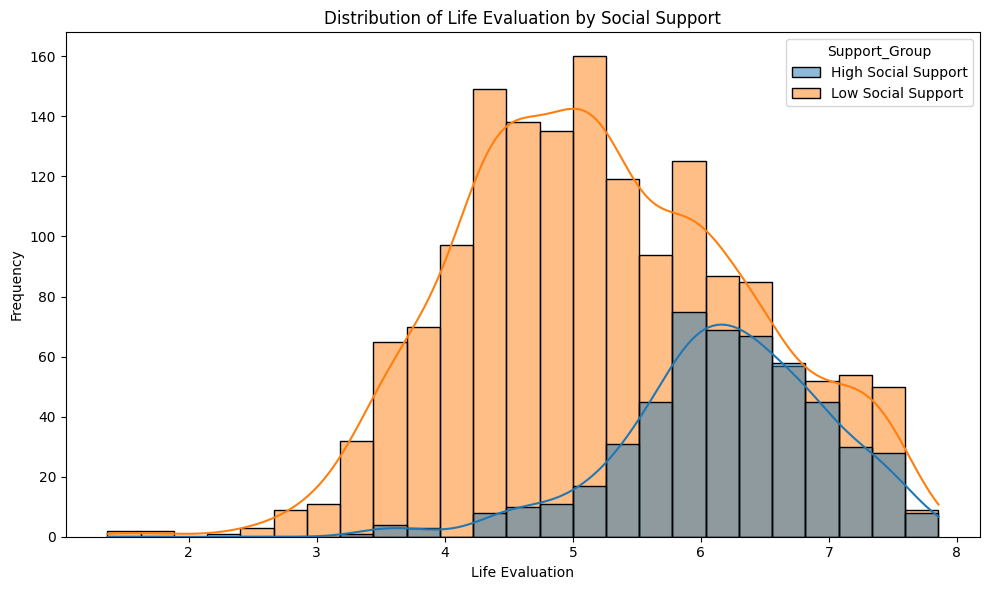

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Life_Evaluation",
    hue="Support_Group",
    kde=True,
    bins=25
)

plt.title("Distribution of Life Evaluation by Social Support")
plt.xlabel("Life Evaluation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

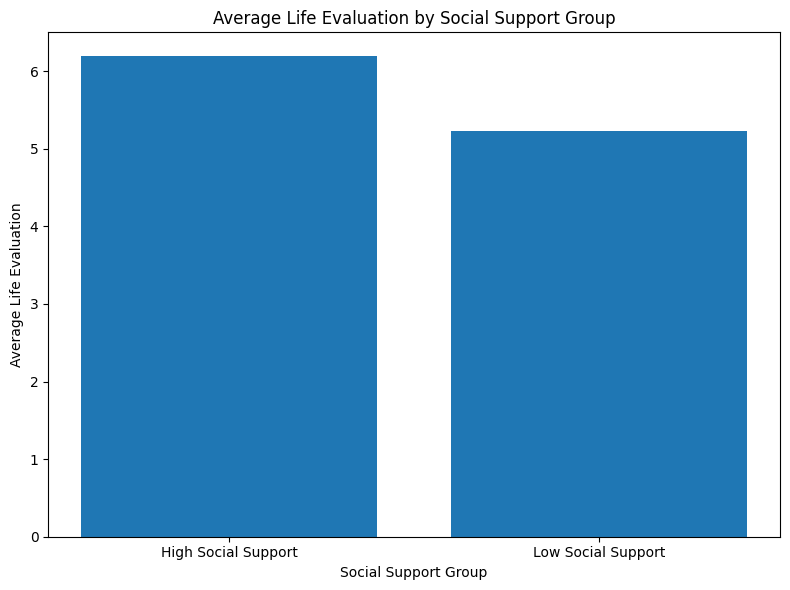

In [13]:
means = df.groupby("Support_Group")["Life_Evaluation"].mean()

plt.figure(figsize=(8, 6))

plt.bar(
    means.index,
    means.values
)

plt.title("Average Life Evaluation by Social Support Group")
plt.xlabel("Social Support Group")
plt.ylabel("Average Life Evaluation")

plt.tight_layout()
plt.show()

In [15]:
high_support = df[
    df["Support_Group"] == "High Social Support"
]["Life_Evaluation"].dropna()

low_support = df[
    df["Support_Group"] == "Low Social Support"
]["Life_Evaluation"].dropna()
t_stat, p_value = stats.ttest_ind(
    high_support,
    low_support,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 21.349316617638674
p-value: 5.8955689150440865e-86


In [16]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference between the groups.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that the groups differ.")

Reject the null hypothesis.
There is a statistically significant difference between the groups.


In [18]:
mean_high = high_support.mean()
mean_low = low_support.mean()

mean_difference = mean_high - mean_low

print("High Support Mean:", mean_high)
print("Low Support Mean:", mean_low)
print("Mean Difference:", mean_difference)

n1 = len(high_support)
n2 = len(low_support)

mean1 = high_support.mean()
mean2 = low_support.mean()

var1 = high_support.var(ddof=1)
var2 = low_support.var(ddof=1)

se = np.sqrt(var1/n1 + var2/n2)

df_welch = (var1/n1 + var2/n2)**2 / (
    ((var1/n1)**2)/(n1-1) +
    ((var2/n2)**2)/(n2-1)
)

t_critical = stats.t.ppf(0.975, df_welch)

difference = mean1 - mean2

ci_lower = difference - t_critical * se
ci_upper = difference + t_critical * se

print("Mean Difference:", difference)
print("95% CI:", ci_lower, "to", ci_upper)

High Support Mean: 6.192130588538973
Low Support Mean: 5.234955852341088
Mean Difference: 0.9571747361978851
Mean Difference: 0.9571747361978851
95% CI: 0.8692128646455292 to 1.045136607750241


In [19]:
pooled_std = np.sqrt(
    ((n1 - 1) * var1 + (n2 - 1) * var2)
    / (n1 + n2 - 2)
)

cohens_d = difference / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 0.9143255124859626


In [20]:
correlation, correlation_p = stats.pearsonr(
    df["Social_Support"].dropna(),
    df.loc[df["Social_Support"].notna(), "Life_Evaluation"]
)

print("Pearson correlation:", correlation)
print("Correlation p-value:", correlation_p)

Pearson correlation: 0.701407522407388
Correlation p-value: 9.894872569772454e-152


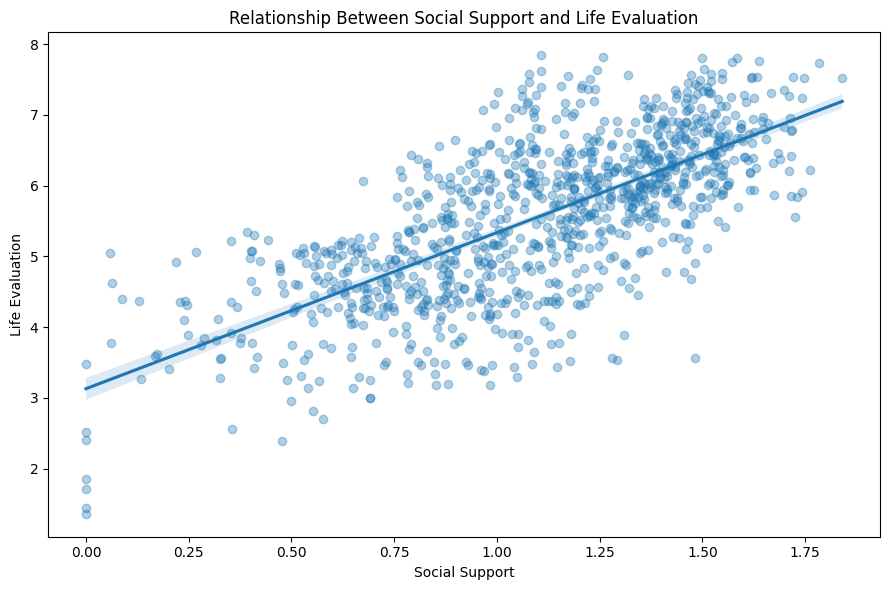

In [21]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="Social_Support",
    y="Life_Evaluation",
    scatter_kws={"alpha": 0.35}
)

plt.title("Relationship Between Social Support and Life Evaluation")
plt.xlabel("Social Support")
plt.ylabel("Life Evaluation")

plt.tight_layout()
plt.show()

In [22]:
print("=" * 50)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 50)

print(f"High Social Support Mean: {mean_high:.4f}")
print(f"Low Social Support Mean: {mean_low:.4f}")
print(f"Mean Difference: {difference:.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"Cohen's d: {cohens_d:.4f}")
print(f"Pearson Correlation: {correlation:.4f}")
print(f"Correlation p-value: {correlation_p:.6f}")

STATISTICAL ANALYSIS SUMMARY
High Social Support Mean: 6.1921
Low Social Support Mean: 5.2350
Mean Difference: 0.9572
t-statistic: 21.3493
p-value: 0.000000
95% CI: (0.8692, 1.0451)
Cohen's d: 0.9143
Pearson Correlation: 0.7014
Correlation p-value: 0.000000


In [24]:
print("High Social Support observations:", len(high_support))
print("Low Social Support observations:", len(low_support))

print("\nGroup Statistics:")
print(group_stats)
print(f"t-test p-value: {p_value:.10e}")
print(f"Correlation p-value: {correlation_p:.10e}")

High Social Support observations: 510
Low Social Support observations: 1606

Group Statistics:
                     count      mean       std   median
Support_Group                                          
High Social Support    510  6.192131  0.793865  6.21825
Low Social Support    1606  5.234956  1.115175  5.14900
t-test p-value: 5.8955689150e-86
Correlation p-value: 9.8948725698e-152
